<a href="https://colab.research.google.com/github/vs-152/FL-Contributions-Incentives-Project/blob/main/ISO_CIFAR10_OR_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─────────────────────────────────────────────────────────────
#  Imports
# ─────────────────────────────────────────────────────────────
import os
import copy
import time
import glob
import shutil
import tempfile
from itertools import chain, combinations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.special import comb
import matplotlib.pyplot as plt
from tqdm import tqdm
import nibabel as nib
import pulp
import onnxruntime
import random

# ─────────────────────────────────────────────────────────────
#  MONAI
# ─────────────────────────────────────────────────────────────
from monai.config import print_config
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, decollate_batch
from monai.handlers.utils import from_engine
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.networks.nets import SegResNet
from monai.apps import DecathlonDataset
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    ScaleIntensityd,
    Spacingd,
    SelectItemsd
)

# ─────────────────────────────────────────────────────────────
#  Custom Modules
# ─────────────────────────────────────────────────────────────
from utils import *

# ─────────────────────────────────────────────────────────────
#  Device & Setup
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print_config()
set_determinism(seed=0)


2026-03-05 13:11:27.053170113 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


MONAI version: 1.6.dev2542
Numpy version: 2.1.2
Pytorch version: 2.8.0+cu126
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 612f3dd3cba4d73cfcea4b5329079e20aa31523d
MONAI __file__: /home/<username>/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: 5.4.4
Nibabel version: 5.3.2
scikit-image version: 0.25.2
scipy version: 1.15.3
Pillow version: 11.0.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.23.0+cu126
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.0.0
pandas version: 2.3.2
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For d

In [2]:
# Corrected conversion for FeTS labels
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    FeTS/BraTS label mapping (ints on disk): 0=background, 1=NCR/NET, 2=edema, 4=enhancing (ET)
    Build 3-channel multi-label [TC, WT, ET]:
      TC = (label==1) OR (label==4)
      WT = (label==1) OR (label==2) OR (label==4)
      ET = (label==4)
    """
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            lab = d[key]
            tc = torch.logical_or(lab == 1, lab == 4)
            wt = torch.logical_or(torch.logical_or(lab == 1, lab == 2), lab == 4)
            et = (lab == 4)
            d[key] = torch.stack([tc, wt, et], dim=0).float()
        return d


train_transform = Compose(
    [
        # load 4 Nifti images and stack them together
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
        RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
    ]
)
val_transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys="image"),
        EnsureTyped(keys=["image", "label"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ]
)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# -----------------------------------------------------------
# 0. paths & meta-data (unchanged) ---------------------------
# -----------------------------------------------------------
BRATS_DIR = "/mnt/d/Datasets/FETS_data/MICCAI_FeTS2022_TrainingData"
CSV_PATH  = f"{BRATS_DIR}/partitioning_1.csv"
MODALITIES = ["flair", "t1", "t1ce", "t2"]
LABEL_KEY  = "seg"

import pandas as pd

# --- Load partition CSV ---
part_df = pd.read_csv(CSV_PATH)

# --- Count subjects per site ---
site_counts = part_df.groupby("Partition_ID")["Subject_ID"].nunique()

# print("Subjects per Site:")
# for site, count in site_counts.items():
#     print(f"Site {site}: {count} subjects")

site_counts = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .nunique()
           .sort_values(ascending=False)
)

print(site_counts)


Partition_ID
1     511
18    382
4      47
13     35
21     35
6      34
20     33
16     30
5      22
3      15
11     14
15     13
7      12
12     11
17      9
10      8
8       8
22      7
2       6
14      6
23      5
9       4
19      4
Name: Subject_ID, dtype: int64


In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# -----------------------------------------------------------
# 0. paths & meta-data (unchanged) ---------------------------
# -----------------------------------------------------------
BRATS_DIR = "/mnt/d/Datasets/FETS_data/MICCAI_FeTS2022_TrainingData"
CSV_PATH  = f"{BRATS_DIR}/partitioning_1.csv"
MODALITIES = ["flair", "t1", "t1ce", "t2"]
LABEL_KEY  = "seg"

# -----------------------------------------------------------
# 1. read partition file  ➜  { id : [subjects] } ------------
# -----------------------------------------------------------
part_df = pd.read_csv(CSV_PATH)

# --- compute subject counts per site -----------------------
site_counts = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .nunique()
)

TOP_K = 6  # keep 6 most populated sites for training

# site IDs for training (top-K by subject count)
TRAIN_CENTRES = set(
    site_counts.sort_values(ascending=False)
               .head(TOP_K)
               .index.tolist()
)

# everything else is validation
VAL_CENTRES = set(site_counts.index) - TRAIN_CENTRES

print("Train centres (top 6 by subject count):")
print(site_counts.loc[sorted(TRAIN_CENTRES)])
print("\nValidation centres (remaining):")
print(site_counts.loc[sorted(VAL_CENTRES)])

# map centre → list of subject IDs
partition_map = (
    part_df.groupby("Partition_ID")["Subject_ID"]
           .apply(list).to_dict()
)

# split once, reuse everywhere
train_partitions = {
    cid: sids for cid, sids in partition_map.items()
    if cid in TRAIN_CENTRES
}
val_subjects = sum((partition_map[cid] for cid in VAL_CENTRES), [])


# -----------------------------------------------------------
# 2. helper to build MONAI-style record dicts ----------------
# -----------------------------------------------------------
def build_records(subject_ids):
    recs = []
    for sid in subject_ids:
        sdir = f"{BRATS_DIR}/{sid}"
        images = [f"{sdir}/{sid}_{m}.nii.gz" for m in MODALITIES]  # 4 modalities
        recs.append({"image": images, "label": f"{sdir}/{sid}_{LABEL_KEY}.nii.gz"})
    return recs


# -----------------------------------------------------------
# 3. MONAI CacheDatasets ------------------------------------
# -----------------------------------------------------------
FRAC, SEED = 1, 42   # FRAC for subsampling within each site
rng = random.Random(SEED)

train_datasets = {}
for cid, subj_ids in train_partitions.items():
    k = max(1, int(len(subj_ids) * FRAC))   # e.g. 0.3 for 30% subsample
    sample_ids = rng.sample(subj_ids, k)
    train_datasets[cid] = CacheDataset(
        build_records(sample_ids), transform=train_transform, cache_rate=1
    )

# ── single validation dataset made from *all* val subjects ─
val_dataset = CacheDataset(
    build_records(val_subjects), transform=val_transform, cache_rate=1
)

print("train per-centre sizes:", {k: len(v) for k, v in train_datasets.items()})
print("validation size:", len(val_dataset))


Train centres (top 6 by subject count):
Partition_ID
1     511
4      47
6      34
13     35
18    382
21     35
Name: Subject_ID, dtype: int64

Validation centres (remaining):
Partition_ID
2      6
3     15
5     22
7     12
8      8
9      4
10     8
11    14
12    11
14     6
15    13
16    30
17     9
19     4
20    33
22     7
23     5
Name: Subject_ID, dtype: int64


Loading dataset: 100%|████████████████████████████████████████████████████████████████| 207/207 [06:33<00:00,  1.90s/it]

train per-centre sizes: {1: 511, 4: 47, 6: 34, 13: 35, 18: 382, 21: 35}
validation size: 207


# SimCLR data handling

In [5]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Contrastive Transform (image only)
# ─────────────────────────────────────────────────────────────

from monai.transforms import RandRotate90d, RandGaussianNoised

simclr_2d_transform = Compose(
    [
        EnsureTyped(keys="image"),
        RandFlipd(keys="image", prob=0.5, spatial_axis=0),
        RandFlipd(keys="image", prob=0.5, spatial_axis=1),
        RandRotate90d(keys="image", prob=0.5),
        # RandScaleIntensityd(keys="image", factors=0.1, prob=0.8),
        # RandShiftIntensityd(keys="image", offsets=0.1, prob=0.8),
        # RandGaussianNoised(keys="image", prob=0.5),
    ]
)

class SimCLR2DDataset(Dataset):
    def __init__(self, monai_dataset, transform):
        self.dataset = monai_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]
        img = data["image"]  # [C, H, W, D]

        # Random axial slice
        depth = img.shape[-1]
        z = torch.randint(0, depth, (1,)).item()
        slice_2d = img[..., z]  # [C, H, W]

        # Wrap as dict for MONAI transforms
        slice_dict = {"image": slice_2d}

        view1 = self.transform(slice_dict)["image"]
        view2 = self.transform(slice_dict)["image"]

        return view1, view2
        
simclr_train_datasets = {
    cid: SimCLR2DDataset(ds, simclr_2d_transform)
    for cid, ds in train_datasets.items()
}

from torch.utils.data import ConcatDataset

simclr_pooled_dataset = ConcatDataset(
    list(simclr_train_datasets.values())
)

simclr_loader = DataLoader(
    simclr_pooled_dataset,
    batch_size=32,   # now we can go bigger
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

In [6]:
v1, v2 = next(iter(simclr_loader))
print(v1.shape, v2.shape)

torch.Size([32, 4, 224, 224]) torch.Size([32, 4, 224, 224])


#  SimCLR model

✅ Step 1 — Define Encoder + Projection Head

In [7]:
# ─────────────────────────────────────────────────────────────
#  SimCLR Model (2D)
# ─────────────────────────────────────────────────────────────
from monai.networks.nets import resnet

class SimCLR2D(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()

        # 2D ResNet18
        self.encoder = resnet.resnet18(
            spatial_dims=2,
            n_input_channels=4,  # 4 MRI modalities
            num_classes=512
        )

        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return h, z


model = SimCLR2D().to(device)

✅ Step 2 — Implement NT-Xent Loss

In [8]:
import torch.nn.functional as F

def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    representations = torch.cat([z1, z2], dim=0)

    similarity_matrix = torch.matmul(representations, representations.T)

    labels = torch.arange(batch_size).to(device)
    labels = torch.cat([labels, labels], dim=0)

    mask = torch.eye(labels.shape[0], dtype=torch.bool).to(device)
    similarity_matrix = similarity_matrix[~mask].view(labels.shape[0], -1)

    positives = torch.cat([
        torch.sum(z1 * z2, dim=1),
        torch.sum(z2 * z1, dim=1)
    ], dim=0)

    logits = similarity_matrix / temperature
    positives = positives / temperature

    loss = -torch.log(
        torch.exp(positives) /
        torch.sum(torch.exp(logits), dim=1)
    )

    return loss.mean()

✅ Step 3 — Training Loop (Minimal Version)

In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

epochs = 50
best_loss = float("inf")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for v1, v2 in tqdm(simclr_loader):
        v1 = v1.to(device)
        v2 = v2.to(device)

        _, z1 = model(v1)
        _, z2 = model(v2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ---- end of epoch ----
    scheduler.step()

    epoch_loss = total_loss / len(simclr_loader)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "./simclr_models/simclr_2d_best.pt")

100%|███████████████████████████████████████████████████████████████████████████████████| 33/33 [04:08<00:00,  7.52s/it]


Epoch 1, Loss: 2.7860


100%|███████████████████████████████████████████████████████████████████████████████████| 33/33 [04:03<00:00,  7.37s/it]


Epoch 2, Loss: 2.5092


100%|███████████████████████████████████████████████████████████████████████████████████| 33/33 [04:08<00:00,  7.54s/it]


...

Epoch 48, Loss: 2.2571


100%|███████████████████████████████████████████████████████████████████████████████████| 33/33 [03:46<00:00,  6.87s/it]


Epoch 49, Loss: 2.2549


100%|███████████████████████████████████████████████████████████████████████████████████| 33/33 [04:00<00:00,  7.29s/it]


Epoch 50, Loss: 2.2546


In [10]:
model.load_state_dict(torch.load("./simclr_models/simclr_2d_best.pt"))
model.eval()

SimCLR2D(
  (encoder): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): ResNetBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_ru

# Build Per-Site Embedding Extractor

In [11]:
def extract_site_embeddings(site_dataset, model, device):
    loader = DataLoader(
        site_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    all_embeddings = []

    with torch.no_grad():
        for v1, _ in loader:   # only need one view
            v1 = v1.to(device)
            h, _ = model(v1)
            all_embeddings.append(h.cpu())

    return torch.cat(all_embeddings, dim=0)

site_embeddings = {}

for cid, dataset in simclr_train_datasets.items():
    print(f"Extracting embeddings for site {cid}")
    site_embeddings[cid] = extract_site_embeddings(dataset, model, device)

Extracting embeddings for site 1
Extracting embeddings for site 4
Extracting embeddings for site 6
Extracting embeddings for site 13
Extracting embeddings for site 18
Extracting embeddings for site 21


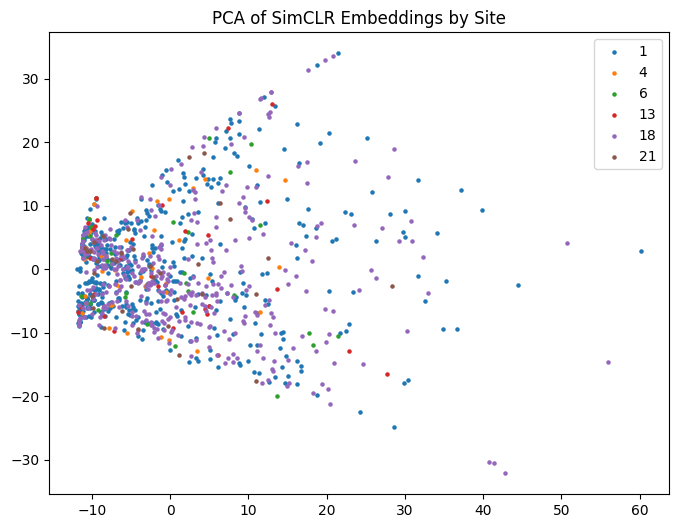

In [12]:
all_embs = []
labels = []

for i, (cid, emb) in enumerate(site_embeddings.items()):
    all_embs.append(emb)
    labels.extend([i] * emb.shape[0])

all_embs = torch.cat(all_embs).numpy()
labels = np.array(labels)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(all_embs)

plt.figure(figsize=(8,6))
for i, cid in enumerate(site_embeddings.keys()):
    mask = labels == i
    plt.scatter(proj[mask, 0], proj[mask, 1], s=5, label=str(cid))

plt.legend()
plt.title("PCA of SimCLR Embeddings by Site")
plt.savefig("./plots/pca_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()

# having learned representations what next?

In [13]:
max_epochs = 300
val_interval = 1
VAL_AMP = True

# create SegResNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
global_model = SegResNet(
    blocks_down=[1, 2, 2, 4],
    blocks_up=[1, 1, 1],
    init_filters=16,
    in_channels=4,
    out_channels=3,
    dropout_prob=0.2,
).to(device)
loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.Adam(global_model.parameters(), 1e-4, weight_decay=1e-5)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

# use amp to accelerate training
scaler = torch.GradScaler("cuda")
# enable cuDNN benchmark
torch.backends.cudnn.benchmark = True

In [14]:
def evaluate_model(model, dataset, device, batch_size=1,
                   roi_size=(128, 128, 64), sw_batch_size=4):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    dice_metric.reset()
    dice_metric_batch.reset()
    model.eval()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            inputs = batch["image"].to(device)
            labels = batch["label"].to(device)          # [B, 3, D, H, W]

            logits = sliding_window_inference(
                inputs=inputs,
                roi_size=roi_size,
                sw_batch_size=sw_batch_size,
                predictor=model,                        # ← use THIS model
            )

            preds = torch.sigmoid(logits)
            preds = (preds > 0.5).float()

            dice_metric(y_pred=preds, y=labels)
            dice_metric_batch(y_pred=preds, y=labels)

    mean_dice = dice_metric.aggregate().item()
    metric_batch = dice_metric_batch.aggregate()
    metric_tc = metric_batch[0].item()
    metric_wt = metric_batch[1].item()
    metric_et = metric_batch[2].item()
    dice_metric.reset()
    dice_metric_batch.reset()

    return mean_dice, metric_tc, metric_wt, metric_et
    
print("Dice before any training:", evaluate_model(global_model, val_dataset, device)) # quick sanity check


Evaluating:   0%|                                                                               | 0/207 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:306.)
Evaluating: 100%|█████████████████████████████████████████████████████████████████████| 207/207 [01:41<00:00,  2.03it/s]

Dice before any training: (0.022270740941166878, 0.05149240419268608, 0.007731999736279249, 0.005998138338327408)


In [15]:
# ─────────────────────────────────────────────────────────────
#  Federation setup
# ─────────────────────────────────────────────────────────────
# train_datasets: dict[int -> MONAI CacheDataset]  (already built)
idxs_users = list(sorted(train_datasets.keys()))
N = len(idxs_users)
print(f"We got {N} clients")

# Fed hyperparams (align with your working pipeline)
ROUNDS       = 50            # you can raise later (e.g., 100)
LOCAL_EPOCHS = 1
LR           = 1e-4
BATCH        = 1

# Client sizes & FedAvg fractions
sizes     = {k: len(ds) for k, ds in train_datasets.items()}
total_n   = sum(sizes.values())
fractions = [sizes[k] / total_n for k in idxs_users]

# Where to persist submodels / global snapshots
submodel_dir = "submodels"
os.makedirs(submodel_dir, exist_ok=True)
submodel_file_template = os.path.join(submodel_dir, "submodel_{}.pth")
global_model_path      = os.path.join(submodel_dir, "global_model.pth")
best_model_path        = os.path.join(submodel_dir, "best_metric_model.pth")

# Save initial global (round 0) – useful for baselines
torch.save(global_model.state_dict(), global_model_path)

# For later Shapley steps
accuracy_dict = {}     # coalition -> utility (e.g., Dice on test set)
shapley_dict  = {}     # client -> shapley value (to be filled later)

# fast sanity check before any training
print("Dice before any training:", evaluate_model(global_model, val_dataset, device))


We got 6 clients


Evaluating: 100%|█████████████████████████████████████████████████████████████████████| 207/207 [01:38<00:00,  2.11it/s]

Dice before any training: (0.022270740941166878, 0.05149240419268608, 0.007731999736279249, 0.005998138338327408)


In [16]:
from tqdm.auto import tqdm, trange   # trange == tqdm(range())
from collections import OrderedDict

def average_weights(state_dicts, fractions):
    """
    Federated averaging with client fractions (must sum to 1).
    state_dicts: list of state_dicts (same keys)
    fractions:   list of floats, same length, sum≈1
    """
    avg_sd = OrderedDict()
    for k in state_dicts[0].keys():
        avg = 0.0
        for sd, w in zip(state_dicts, fractions):
            avg += sd[k] * w
        avg_sd[k] = avg
    return avg_sd

# ────────────────────────────────────────────────────────────
# 1. one-client update (returns weights + mean loss)          │
# ────────────────────────────────────────────────────────────
def local_train(model, loader, device, lr=1e-4, epochs=1):
    """
    Train a local copy of the global model on one client's DataLoader.
    Uses your DiceLoss (multi-label, sigmoid) and full crops from transforms.
    """
    model = copy.deepcopy(model).to(device)
    model.train()

    # reuse your loss choice; or inline DiceLoss the same way
    crit = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True,
                    to_onehot_y=False, sigmoid=True).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    epoch_losses = []

    for _ in range(epochs):
        running = 0.0
        for batch in loader:
            img = batch["image"].to(device)   # [B, 4, D, H, W]
            msk = batch["label"].to(device)   # [B, 3, D, H, W]

            opt.zero_grad(set_to_none=True)
            logits = model(img)               # [B, 3, D, H, W]
            loss = crit(logits, msk)
            loss.backward()
            opt.step()

            running += float(loss.item())
        epoch_losses.append(running / max(1, len(loader)))

    return model.state_dict(), float(np.mean(epoch_losses))


# ─────────────────────────────────────────────────────────────
#  FedAvg training loop (with per-client snapshots each round)
# ─────────────────────────────────────────────────────────────
from tqdm.auto import tqdm, trange
from collections import OrderedDict

best_metric = -1
best_metric_round = -1
best_metrics_rounds_and_time = [[], [], []]   # best, round, seconds
round_loss_values = []
metric_values     = []
metric_values_tc  = []
metric_values_wt  = []
metric_values_et  = []

patience      = 10      # stop after 5 rounds with no improvement
no_improve    = 0
start_time    = time.time()
last_round_run = 0     # track actual last round (for logging)

for rnd in trange(1, ROUNDS + 1, desc="Global rounds", position=0, leave=True, dynamic_ncols=True):
    local_weights, client_losses = [], []

    # —— local updates per client ——
    for cid in tqdm(idxs_users, desc=" clients", position=1, leave=False, total=len(idxs_users), dynamic_ncols=True):
        loader = DataLoader(
            train_datasets[cid], batch_size=BATCH, shuffle=True,
            num_workers=4, pin_memory=True
        )
        w, loss = local_train(global_model, loader, device, lr=LR, epochs=LOCAL_EPOCHS)
        local_weights.append(w); client_losses.append(loss)

        # Persist this client's *latest* local model for Shapley / ablations
        torch.save(w, submodel_file_template.format(cid))

    # —— FedAvg (fraction-weighted) ——
    global_model.load_state_dict(average_weights(local_weights, fractions))

    # —— validation metrics on your current pipeline ——
    mean_dice, metric_tc, metric_wt, metric_et = evaluate_model(global_model, val_dataset, device)
    metric_values.append(mean_dice)
    metric_values_tc.append(metric_tc)
    metric_values_wt.append(metric_wt)
    metric_values_et.append(metric_et)

    mean_loss = float(np.mean(client_losses))
    round_loss_values.append(mean_loss)

    # —— track best & save ——
    if mean_dice > best_metric:
        best_metric = mean_dice
        best_metric_round = rnd
        best_metrics_rounds_and_time[0].append(best_metric)
        best_metrics_rounds_and_time[1].append(best_metric_round)
        best_metrics_rounds_and_time[2].append(time.time() - start_time)
        torch.save(global_model.state_dict(), best_model_path)
        print("saved new best metric model")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping triggered at round {rnd} (no improvement for {patience} rounds).")
            break

    tqdm.write(
        f"Round {rnd:02d}: mean-loss={mean_loss:.4f} "
        f"mean-Dice={mean_dice:.4f}  "
        f"TC-Dice={metric_tc:.4f}  WT-Dice={metric_wt:.4f}  ET-Dice={metric_et:.4f}"
    )

# ── final val utility for the “grand coalition” (all clients) ─────────────
val_mean_dice, val_tc, val_wt, val_et = evaluate_model(global_model, val_dataset, device)
print(f"\nResults after {ROUNDS} global rounds:")
print(f"|---- Val Dice(mean): {val_mean_dice:.4f} | TC {val_tc:.4f} | WT {val_wt:.4f} | ET {val_et:.4f}")

# Store utility for coalition = all clients (tuple keeps order deterministic)
accuracy_dict[tuple(idxs_users)] = val_mean_dice



Global rounds:   0%|                                                                             | 0/50 [00:00…

 clients:   0%|                                                                                   | 0/6 [00:00…

Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]

saved new best metric model
Round 01: mean-loss=0.9072 mean-Dice=0.3397  TC-Dice=0.3399  WT-Dice=0.6391  ET-Dice=0.0061


 clients:   0%|                                                                                   | 0/6 [00:00…

...

 clients:   0%|                                                                                   | 0/6 [00:00…

Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]

Early stopping triggered at round 30 (no improvement for 10 rounds).


Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]


Results after 50 global rounds:
|---- Val Dice(mean): 0.6561 | TC 0.5565 | WT 0.8085 | ET 0.6241


In [ ]:
# ── deterministic powerset over your sorted client IDs (exclude empty, include all) ──
clients = list(sorted(idxs_users))                       # e.g., [1,2,3,...] or arbitrary ints
powerset = [tuple(s) for r in range(1, len(clients)+1)   # nonempty subsets only
            for s in combinations(clients, r)]

# Build a client -> fraction map (global FedAvg fractions you already computed)
fraction_map = {cid: frac for cid, frac in zip(clients, fractions)}

# Helper: renormalize fractions within a subset so they sum to 1
def subset_weights_and_fracs(subset):
    w_list = [torch.load(submodel_file_template.format(cid)) for cid in subset]
    raw_fracs = np.array([fraction_map[cid] for cid in subset], dtype=float)
    raw_sum = float(raw_fracs.sum())
    if raw_sum <= 0:
        # fallback to uniform if something odd happens
        norm_fracs = [1.0 / len(subset)] * len(subset)
    else:
        norm_fracs = (raw_fracs / raw_sum).tolist()
    return w_list, norm_fracs

# Evaluate every proper coalition (exclude the grand coalition at first)
# If you want all, use `powerset`; if you want proper only, do `powerset[:-1]` as you had.
for subset in powerset[:-1]:
    # 1) aggregate weights
    if len(subset) == 1:
        subset_sd = torch.load(submodel_file_template.format(subset[0]))
    else:
        w_list, norm_fracs = subset_weights_and_fracs(subset)
        subset_sd = average_weights(w_list, norm_fracs)

    # 2) build a model with identical arch/buffers and load weights
    submodel = copy.deepcopy(global_model).to(device)
    submodel.load_state_dict(subset_sd)
    submodel.eval()

    # 3) evaluate with your current pipeline’s evaluator
    mean_dice, metric_tc, metric_wt, metric_et = evaluate_model(submodel, val_dataset, device)

    # 4) record utility
    accuracy_dict[subset] = float(mean_dice)

    print(f"\nCoalition {subset}: mean Val Dice={mean_dice:.4f} | TC={metric_tc:.4f} | WT={metric_wt:.4f} | ET={metric_et:.4f}")

    # free promptly
    del submodel
    torch.cuda.empty_cache()

# Optionally ensure the grand coalition utility is present (you stored it earlier, but just in case)
grand = tuple(clients)
if grand not in accuracy_dict:
    m, tc, wt, et = evaluate_model(global_model, val_dataset, device)
    accuracy_dict[grand] = float(m)



Evaluating:   0%|          | 0/207 [00:02<?, ?it/s]


Coalition (1,): mean Val Dice=0.6784 | TC=0.5890 | WT=0.8037 | ET=0.6666


Evaluating:   0%|          | 0/207 [00:02<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa4917a93f0>
Traceback (most recent call last):
  File "/home/locolinux2/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/home/locolinux2/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
  File "/home/locolinux2/miniconda3/envs/m_quant_py310/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fa4917a93f0>
Traceback (most recent call last):
  File "/home/locolinux2/miniconda3/envs/m_quant_py310/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
 


Coalition (4,): mean Val Dice=0.7024 | TC=0.6368 | WT=0.8486 | ET=0.6389


...

Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]


Coalition (1, 21): mean Val Dice=0.6925 | TC=0.6050 | WT=0.8129 | ET=0.6849


Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]


Coalition (4, 6): mean Val Dice=0.7339 | TC=0.6637 | WT=0.8588 | ET=0.7023


Evaluating:   0%|          | 0/207 [00:01<?, ?it/s]

In [ ]:
# Sanity check
# Confirm submodels differ (they should):
import torch

def l2_diff(sd1, sd2):
    s = 0.0 
    for k in sd1:
        s += torch.sum((sd1[k] - sd2[k])**2).item()
    return s

w1 = torch.load(submodel_file_template.format(clients[0]))
w2 = torch.load(submodel_file_template.format(clients[1]))
print("L2 diff between client 1 and 2:", l2_diff(w1, w2))


In [ ]:
# utility of the empty coalition is 0 by definition
accuracy_dict[()] = 0.0

# ── Shapley & Least Core ─────────────────────────────────────────────────
trainTime = time.time() - start_time
start_time = time.time()
shapley_dict = shapley(accuracy_dict, len(clients))
shapTime = time.time() - start_time

start_time = time.time()
lc_dict = least_core(accuracy_dict, len(clients))
LCTime = time.time() - start_time

totalShapTime = trainTime + shapTime
totalLCTime   = trainTime + LCTime
print(f"\n Grand-coalition validation utility (Dice): {accuracy_dict[grand]:.4f}")
print(f" Total Time Shapley: {totalShapTime:0.4f}s")
print(f" Total Time LC:      {totalLCTime:0.4f}s")


In [ ]:
accuracy_dict

In [ ]:
print("Shapley allocation:")
for cid, phi in shapley_dict.items():
    print(f" client {cid}: {phi:.4f}")

print("\nLeast-Core allocation:")
for var in lc_dict.variables():
    if var.name.startswith("x("):
        print(f" client {var.name[2:-1]}: {var.value():.4f}")
print(f" e (slack): {lc_dict.variablesDict()['e'].value():.4f}")


In [ ]:
def stats(vector):
    n = len(vector)
    egal = np.array([1/n for i in range(n)])
    normalised = np.array(vector / vector.sum())
    msg = f'Original vector: {vector}\n'
    msg += f'Normalised vector: {normalised}\n'
    msg += f'Max Dif: {normalised.max()-normalised.min()}\n'
    msg += f'Distance: {np.linalg.norm(normalised-egal)}\n'

    msg += f'Budget: {vector.sum()}\n'
    print(msg)

In [ ]:
stats(np.array(list(shapley_dict.values())))

In [ ]:
stats(np.array([i.value() for i in lc_dict.variables()])[1:])